Mounted at /content/drive
Found 1133 images belonging to 2 classes.
Found 282 images belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 277s 7s/step - accuracy: 0.6277 - loss: 0.6956 - val_accuracy: 0.8369 - val_loss: 0.3829
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.8460 - loss: 0.3678 - val_accuracy: 0.9220 - val_loss: 0.2701
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9197 - loss: 0.2673 - val_accuracy: 0.9468 - val_loss: 0.2053
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.9425 - loss: 0.1940 - val_accuracy: 0.9645 - val_loss: 0.1620
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.9790 - loss: 0.1438 - val_accuracy: 0.9645 - val_loss: 0.1324
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.9753 - loss: 0.1338 - val_accuracy: 0.9681 - val_loss: 0.1149
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.9796 - loss: 0.0999 - val_accuracy: 0.9681 - val_loss: 0.1021
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.9848 - loss: 0.0876 - val_accuracy: 0.9716 - val_loss

✅ Model saved to: /content/drive/MyDrive/ML_WSSV/shrimpInfectionDetection/mobilenetv2_model.h5


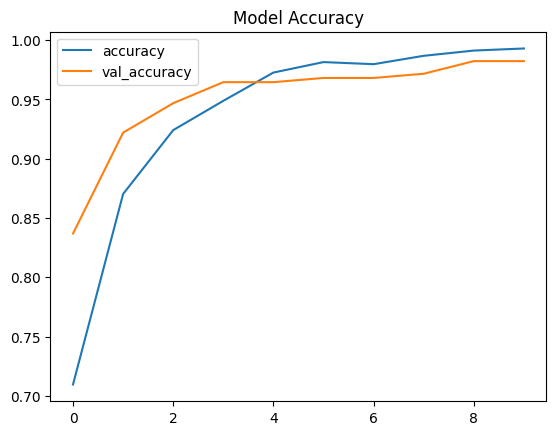

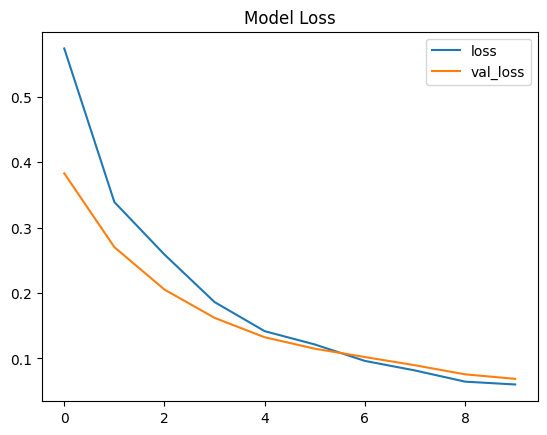

In [ ]:
# STEP 1: Mount Google Drive

# Import Google Drive access module from Google Colab
# This allows the notebook to access files stored in your Google Drive
from google.colab import drive

# Connect (mount) Google Drive so datasets and model files can be accessed
drive.mount('/content/drive')


# STEP 2: Import libraries

# Import OS library
# Used to work with folders and file paths
import os

# Import matplotlib for creating graphs and visualizing results
import matplotlib.pyplot as plt

# Import pandas for organizing and plotting training results
import pandas as pd

# Import TensorFlow library
# TensorFlow is the main framework used for building and training the AI model
import tensorflow as tf

# Import ImageDataGenerator
# This tool loads images from folders and prepares them for training
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Import MobileNetV2 model
# MobileNetV2 is a lightweight deep learning model designed for image classification
# It is commonly used in mobile and embedded AI applications
from tensorflow.keras.applications import MobileNetV2

# Import Model class used to create the final neural network structure
from tensorflow.keras.models import Model

# Import layers used to build the custom classification head
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Import Adam optimizer
# This controls how the model learns during training
from tensorflow.keras.optimizers import Adam


# STEP 3: Define paths

# Define the main dataset folder stored in Google Drive
# This folder contains both training and validation image datasets
base_dir = '/content/drive/MyDrive/ML_WSSV/WSSV/dataset/Augmented_data'

# Define the path to the training dataset
# These images will be used to teach the model how to detect shrimp disease
train_dir = os.path.join(base_dir, 'train')

# Define the path to the validation dataset
# These images will be used to test how well the model learned
val_dir = os.path.join(base_dir, 'validation_data')

# Define where the trained model will be saved
# This file will later be used for prediction (inference)
model_save_path = '/content/drive/MyDrive/ML_WSSV/WSSV/Trained_Model/mobilenetv2_model.h5'


# STEP 4: Data Generators

# Create a training data generator
# rescale=1./255 converts pixel values from range 0–255 to 0–1
# Normalization improves model learning stability
train_datagen = ImageDataGenerator(rescale=1./255)

# Create a validation data generator
# It performs the same normalization for validation images
val_datagen = ImageDataGenerator(rescale=1./255)


# Load training images from the training folder
# target_size=(224,224) resizes images to the size expected by MobileNetV2
# batch_size=32 means 32 images will be processed at one time
# class_mode='binary' because we have two classes: Healthy and WSSV
train_gen = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='binary')

# Load validation images from the validation folder
# These images are used to evaluate model performance during training
val_gen = val_datagen.flow_from_directory(val_dir, target_size=(224, 224), batch_size=32, class_mode='binary')


# STEP 5: Build MobileNetV2 model

# Load MobileNetV2 model with pre-trained weights from ImageNet dataset
# include_top=False removes the original classification layers
# because we will add our own layers for shrimp disease detection
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all layers in the base model
# This keeps the previously learned image features unchanged
base_model.trainable = False


# Get the output feature maps from the base model
x = base_model.output

# Apply Global Average Pooling
# This converts the feature maps into a single vector for classification
x = GlobalAveragePooling2D()(x)

# Add a dense (fully connected) layer with 128 neurons
# This layer learns shrimp disease-related patterns
x = Dense(128, activation='relu')(x)

# Add dropout layer to reduce overfitting
# It randomly disables some neurons during training
x = Dropout(0.3)(x)

# Final output layer
# Since the task is binary classification (Healthy vs WSSV)
# we use a single neuron with sigmoid activation
predictions = Dense(1, activation='sigmoid')(x)


# Create the final model by combining base model and custom layers
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
# optimizer controls how the model updates weights
# loss measures prediction error
# accuracy tracks the percentage of correct predictions
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])


# STEP 6: Train the model

# Train the model using the training dataset
# epochs=10 means the model will see the full dataset 10 times
# validation_data checks performance on unseen validation images
history = model.fit(train_gen, epochs=10, validation_data=val_gen)


# STEP 7: Save the model

# Save the trained model to Google Drive
# This allows the model to be reused later for predictions
model.save(model_save_path)

# Print confirmation message showing where the model was saved
print(f"✅ Model saved to: {model_save_path}")


# STEP 8: Plot accuracy and loss

# Import matplotlib again for plotting graphs
import matplotlib.pyplot as plt

# Plot training accuracy vs validation accuracy
# This graph shows how well the model improved during training
pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()

# Add title to the accuracy graph
plt.title('Model Accuracy')

# Display the graph
plt.show()


# Plot training loss vs validation loss
# Loss shows how far the model predictions are from the correct labels
pd.DataFrame(history.history)[['loss', 'val_loss']].plot()

# Add title to the loss graph
plt.title('Model Loss')

# Display the graph
plt.show()